In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from netCDF4 import Dataset
from scipy.stats import linregress
import statsmodels.api as sm

# ============================================================================
# 1. Load satellite CHL data (same as boxplot script)
# ============================================================================
file_id = Dataset('../../data/chl/chl_1999_2024_day_aloha_l3_2.nc')
# chl_sat = file_id.variables["CHL"][:]
chl_sat = file_id.variables["CHL"][:].filled(np.nan).astype('float64')
sat_time = file_id.variables["time"][:]
sat_lat = file_id.variables["latitude"][:]
sat_lon = file_id.variables["longitude"][:]
file_id.close()

# Build date vector
sat_timedelta = (sat_time * np.timedelta64(1, 'D')).astype('timedelta64[ns]')
sat_dates = pd.to_datetime(np.datetime64('1900-01-01') + sat_timedelta)

# Target: Station ALOHA (22.75°N, 158°W)
target_lat = 22.75
target_lon = -158.0

# Find nearest indices
lat_idx = np.argmin(np.abs(sat_lat - target_lat))
lon_idx = np.argmin(np.abs(sat_lon - target_lon))

# 3x3 spatial box (±1 pixel around center)
lat_slice = slice(lat_idx - 1, lat_idx + 2)
lon_slice = slice(lon_idx - 1, lon_idx + 2)

chl_crop = chl_sat[:, lat_slice, lon_slice]
print(f'Satellite CHL shape: {chl_crop.shape}')
print(f'Satellite date range: {sat_dates[0].date()} to {sat_dates[-1].date()}')
print(f'Center lat: {sat_lat[lat_idx]:.4f}, Center lon: {sat_lon[lon_idx]:.4f}')

# Compute spatial mean of 3x3 box for each time step
sat_spatial_mean = np.nanmean(chl_crop.reshape(chl_crop.shape[0], -1), axis=1)


Satellite CHL shape: (9496, 3, 3)
Satellite date range: 1999-01-01 to 2024-12-30
Center lat: 22.7708, Center lon: -158.0208


/tmp/ipykernel_320291/3725608596.py:41: RuntimeWarning: Mean of empty slice
  sat_spatial_mean = np.nanmean(chl_crop.reshape(chl_crop.shape[0], -1), axis=1)


In [2]:

# ============================================================================
# 2. Load HPLC data from NetCDF
# ============================================================================
file_id = Dataset('../../data/hd130556.nc')

hplc_mdate = file_id.variables["mdate"][:].filled(-9).astype('float64')
hplc_press = file_id.variables["press"][:].filled(-9).astype('float64')
hplc_chl   = file_id.variables["hplc"][:].filled(np.nan).astype('float64')

#hplc_mdate = file_id.variables["mdate"][:].copy()
#hplc_press = file_id.variables["press"][:].copy()
#hplc_chl   = file_id.variables["hplc"][:].copy()
file_id.close()

# Convert mmddyy date format to datetime
def parse_mmddyy(val):
    """Convert mmddyy float to datetime."""
    s = f'{int(val):06d}'
    mm, dd, yy = int(s[:2]), int(s[2:4]), int(s[4:6])
    # Handle century: yy >= 80 → 1900s, else 2000s
    year = 1900 + yy if yy >= 80 else 2000 + yy
    try:
        return pd.Timestamp(year, mm, dd)
    except:
        return pd.NaT

hplc_dates = np.array([parse_mmddyy(d) for d in hplc_mdate])

# Build HPLC dataframe
hplc_df = pd.DataFrame({
    'time': hplc_dates,
    'press': hplc_press,
    'chl': hplc_chl / 1000.0  # convert ng/l to mg/m³ (µg/l)
})

# Remove bad dates
hplc_df = hplc_df.dropna(subset=['time']).copy()

# Filter to upper 25m
hplc_df = hplc_df[hplc_df['press'] < 27].copy()

# Filter to satellite date range
hplc_df = hplc_df[(hplc_df['time'] >= sat_dates.min()) &
                  (hplc_df['time'] <= sat_dates.max())].copy()

# Average across depths for each day
hplc_daily = hplc_df.groupby('time')['chl'].mean().reset_index()

print(f'\nHPLC samples: {len(hplc_daily)}')
print(f'HPLC date range: {hplc_daily["time"].min().date()} to {hplc_daily["time"].max().date()}')



HPLC samples: 241
HPLC date range: 1999-01-14 to 2024-12-21


In [3]:

# ============================================================================
# 3. Match HPLC dates to satellite 3x3x3 boxes
# ============================================================================
# For each HPLC date, find nearest satellite date and compute
# mean of 3×3 spatial × 3 temporal (day before, day of, day after)

calib_records = []
for _, row in hplc_daily.iterrows():
    hplc_date = row['time']
    hplc_val  = row['chl']

    # Find nearest satellite time index
    time_diffs = np.abs(sat_dates - hplc_date)
    nearest_idx = np.argmin(time_diffs)

    # Skip if nearest satellite date is more than 2 days away
    if time_diffs[nearest_idx].days > 2:
        continue

    # 3-day temporal window (day before, day of, day after)
    t_start = max(0, nearest_idx - 1)
    t_end   = min(len(sat_dates), nearest_idx + 2)

    # Mean of 3x3x3 box
    box = chl_crop[t_start:t_end, :, :]
    sat_mean = np.nanmean(box)

    # Skip if all NaN (clouds)
    if np.isnan(sat_mean):
        continue

    calib_records.append({
        'time': hplc_date,
        'hplc_chl': hplc_val,
        'sat_chl': sat_mean
    })

calib = pd.DataFrame(calib_records)
print(f'\nMatched pairs: {len(calib)}')
print(f'Date range: {calib["time"].min().date()} to {calib["time"].max().date()}')



Matched pairs: 212
Date range: 1999-01-14 to 2024-12-21


/tmp/ipykernel_320291/3048493022.py:26: RuntimeWarning: Mean of empty slice
  sat_mean = np.nanmean(box)


In [4]:

# ============================================================================
# 4. Regression: Gamma GLM (identity link) — matching R script
# ============================================================================
x = calib['hplc_chl'].values
y = calib['sat_chl'].values

# Remove any remaining NaN
mask = ~np.isnan(x) & ~np.isnan(y) & (x > 0) & (y > 0)
x = x[mask]
y = y[mask]

# Gamma GLM with identity link (matching R: glm(y ~ x, family = Gamma(link="identity")))
X_glm = sm.add_constant(x)
glm_model = sm.GLM(y, X_glm, family=sm.families.Gamma(sm.families.links.Identity()))
glm_fit = glm_model.fit()

slope_glm = glm_fit.params[1]
intercept_glm = glm_fit.params[0]
deviance = glm_fit.deviance
null_deviance = glm_fit.null_deviance
r2_dev = 1 - deviance / null_deviance

print(f'\n{"="*60}')
print(f'  Gamma GLM (identity link): Sat CHL ~ HPLC CHL')
print(f'{"="*60}')
print(f'  Slope:     {slope_glm:.4f}')
print(f'  Intercept: {intercept_glm:.4f}')
print(f'  R² (dev):  {r2_dev:.4f}')
print(f'  n:         {len(x)}')
print(f'{"="*60}')
print(glm_fit.summary())

# Also compute OLS for comparison
slope_ols, intercept_ols, r_ols, p_ols, se_ols = linregress(x, y)
print(f'\n  OLS: slope={slope_ols:.4f}, intercept={intercept_ols:.4f}, '
      f'R²={r_ols**2:.4f}, p={p_ols:.2e}')



  Gamma GLM (identity link): Sat CHL ~ HPLC CHL
  Slope:     0.4347
  Intercept: 0.0321
  R² (dev):  0.6024
  n:         212
                 Generalized Linear Model Regression Results                  
Dep. Variable:                      y   No. Observations:                  212
Model:                            GLM   Df Residuals:                      210
Model Family:                   Gamma   Df Model:                            1
Link Function:               Identity   Scale:                        0.023730
Method:                          IRLS   Log-Likelihood:                 672.99
Date:                Wed, 22 Apr 2026   Deviance:                       4.7258
Time:                        16:08:28   Pearson chi2:                     4.98
No. Iterations:                     8   Pseudo R-squ. (CS):             0.7591
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
-----

/home/jamesash/anaconda3/envs/uhdas/lib/python3.12/site-packages/statsmodels/genmod/generalized_linear_model.py:308: DomainWarning: The Identity link function does not respect the domain of the Gamma family.
  warnings.warn((f"The {type(family.link).__name__} link function "


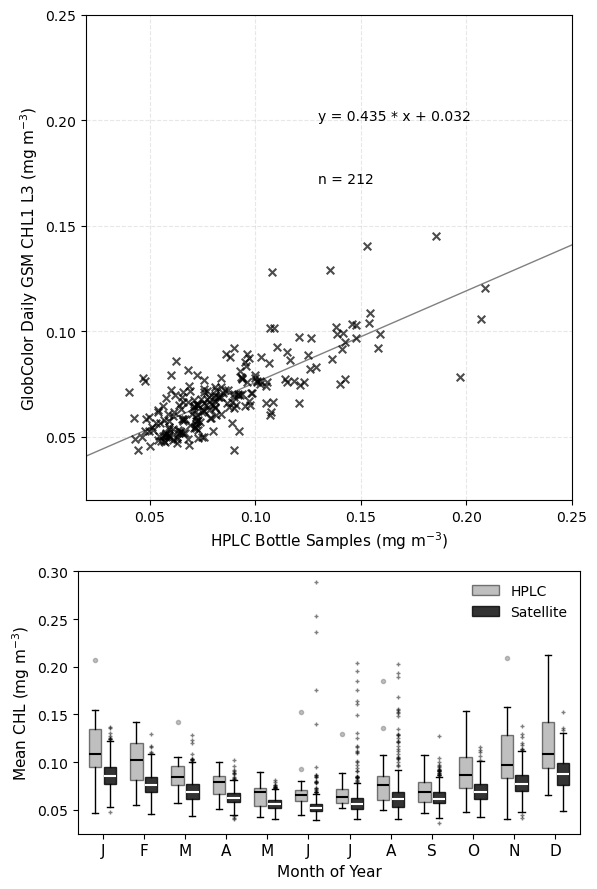


Saved calibration data: 212 matched pairs


In [16]:

# ============================================================================
# 5. Plot: Scatter + Monthly Boxplot (two panels)
# ============================================================================
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(6, 9), gridspec_kw={'height_ratios': [1.85, 1]})

# --- Panel 1: Scatter plot ---
ax1.scatter(x, y, marker='x', color='black', alpha=0.7, s=30, zorder=3)

# Regression line
x_fit = np.linspace(0.02, 0.25, 100)
y_fit = slope_glm * x_fit + intercept_glm
ax1.plot(x_fit, y_fit, color='grey', linewidth=1)

ax1.set_xlim(0.02, 0.25)
ax1.set_ylim(0.02, 0.25)
ax1.set_aspect('equal')
ax1.set_xlabel('HPLC Bottle Samples (mg m$^{-3}$)', fontsize=11)
ax1.set_ylabel('GlobColor Daily GSM CHL1 L3 (mg m$^{-3}$)', fontsize=11)
ax1.text(0.13, 0.20,
         f'y = {slope_glm:.3f} * x + {intercept_glm:.3f}',
         fontsize=10)
ax1.text(0.13, 0.17,
         f'n = {len(x)}',
         fontsize=10)
ax1.grid(True, alpha=0.3, linestyle='--')

# --- Panel 2: Monthly boxplot comparison ---
# Prepare satellite monthly data
sat_df = pd.DataFrame({
    'chl': sat_spatial_mean,
    'month': sat_dates.month,
    'ID': 'Satellite'
})
sat_df = sat_df.dropna()

# Prepare HPLC monthly data
hplc_box = hplc_daily.copy()
hplc_box['month'] = hplc_box['time'].dt.month
hplc_box['ID'] = 'HPLC'
hplc_box = hplc_box[['chl', 'month', 'ID']]

# Combine
box_df = pd.concat([sat_df[['chl', 'month', 'ID']],
                    hplc_box], ignore_index=True)

month_labels = ['J','F','M','A','M','J','J','A','S','O','N','D']
positions_hplc = np.arange(1, 13) - 0.18
positions_sat  = np.arange(1, 13) + 0.18

# HPLC boxplot
hplc_monthly = [box_df[(box_df['ID'] == 'HPLC') & (box_df['month'] == m)]['chl'].dropna().values
                for m in range(1, 13)]
bp1 = ax2.boxplot(hplc_monthly, positions=positions_hplc, widths=0.3,
                  showfliers=True, patch_artist=True,
                  boxprops=dict(facecolor='grey', edgecolor='black', alpha=0.5),
                  medianprops=dict(color='black', linewidth=1.5),
                  whiskerprops=dict(color='black'),
                  capprops=dict(color='black'),
                  flierprops=dict(marker='o', markeredgecolor='grey',
                                  markerfacecolor='grey', markersize=3, alpha=0.5))

# Satellite boxplot
sat_monthly = [box_df[(box_df['ID'] == 'Satellite') & (box_df['month'] == m)]['chl'].dropna().values
               for m in range(1, 13)]
bp2 = ax2.boxplot(sat_monthly, positions=positions_sat, widths=0.3,
                  showfliers=True, patch_artist=True,
                  boxprops=dict(facecolor='black', edgecolor='black', alpha=0.8),
                  medianprops=dict(color='white', linewidth=1.5),
                  whiskerprops=dict(color='black'),
                  capprops=dict(color='black'),
                  flierprops=dict(marker='+', markeredgecolor='black',
                                  markerfacecolor='black', markersize=3, alpha=0.5))

ax2.set_xlim(0.4, 12.6)
ax2.set_ylim(0.025, 0.3)
ax2.set_xticks(range(1, 13))
ax2.set_xticklabels(month_labels, fontsize=11)
ax2.set_xlabel('Month of Year', fontsize=11)
ax2.set_ylabel('Mean CHL (mg m$^{-3}$)', fontsize=11)
ax2.legend([bp1['boxes'][0], bp2['boxes'][0]], ['HPLC', 'Satellite'],
           loc='upper right', fontsize=10, frameon=False)

plt.tight_layout()
fig.savefig('../../figures/hplc_chlsat_calibration_20260422.pdf', dpi=600, bbox_inches='tight', facecolor='white')
fig.savefig('../../figures/hplc_chlsat_calibration_20260422.png', dpi=600, bbox_inches='tight', facecolor='white')
plt.show()

# ============================================================================
# 6. Save calibration data
# ============================================================================
calib.to_csv('../../data/hplc_sat_calibration.csv', index=False)
print(f'\nSaved calibration data: {len(calib)} matched pairs')